#  EDA Part 2 Correlation & Data Storytelling 

#### Main Idea :
Articulating the relationsships between data and how they affect eachother is one of the most important aspects of data analysis. We mostly care about how variables (features) in a data set affect the lable(the target column)

# Load all libraries 

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# EDA Concepts : Visual Exploration

## 1. Bivariate Analysis

> **Bivariate analysis** is a statistical method used to explore the relationship between two variables. The goal is to understand whether and how the two variables are related — and if they are, then describe the nature, strength, and direction of that relationship.
>
> It is a quantitative analysis that examines two variables denoted as X and Y. Bivariate analysis aims to understand to what extent one variable (possibly independent) predicts the value of another (possibly dependent). **It helps uncover correlations and associations between different factors in data analysis.**

### 1.1 **Features and Lables:**

>  **Features**  are the input variables used to make predictions, while **labels** are the target outputs you want the model to learn and predict.

- **Dependent variables** --> lables (target column)
- **Independent variabkes** --> features

### 1.2 Correlation

> Correlation analysis is a statistical technique for determining the strength of a link between two variables. It is used to detect patterns and trends in data and to forecast future occurrences.

- Consider a problem with different factors to be considered for making optimal conclusions
- Correlation explains how these variables are dependent on each other **with a numeric value**
- Correlation quantifies how strong the relationship between two variables is. A higher value of the correlation coefficient implies a stronger association.
- The sign of the correlation coefficient indicates the direction of the relationship between variables. It can be either positive, negative, or zero.

#### how to articulate the relationships between variables

| Label data type |Feature data type | Effect size stat |Visualization|   
|---|---|---|---|
| `numeric` | `numeric` | Pearson correlation $(r)$ | Scatterplot
| `numeric` | `Categorical` | One-way ANOVA $(F)$ | Bar chart
| `categorical` | `categorical` | Pearson chi-square ($x^2$) |CrossTab


#### **Note**
**Types of data:**
 it is important to mention this note as a reminder since data can be continuous and  discrete(non-continuous) and the types of data can determine which method will be used to analyze them.

 - **continuous**
     - Can take any value, including decimals and fractions, within a finite or infinite interval.
     - obtained by measuring
     -  Graphs usually shown with smooth, connected lines or curves. Uses **Histographs** and **Line graphs** to visualize them.
     -  Examples: heights, weights, time.
 - **discrete**
     -  Can only take specific, distinct individual values, usually whole numbers.
     -  Obtained by counting items or events.
     -  Graphs: Usually shown with separate, unconnected points or bars. Uses **bar graphs** to visualize them.
     -  Example: number of students in a classroom.

 Link for brief explanation : https://www.youtube.com/watch?v=g30cI4Kbhb4

### 1.2.1 Numerical Vs Numerical statistics 

> In this type, **both** the independent and dependent variables **are numerical.**

 #### When both variables are numerical:
 
1. We first visualize their relationship using a scatter plot.
2. If the relationship **appears approximately linear**, **we use Pearson correlation** to measure its strength and direction.
  > <img src="Correllation_pearson.png" alt="linear relationship and Pearson correlation" width="500">
3. If the relationship is **monotonic** but not linear, **Spearman correlation** is more appropriate.
  > <img src="spearman_correlation.png" alt="monotonic relationship and Spearman correlation " width="500">
4.  If the relationship is more complex (e.g., U-shaped or periodic), a correlation coefficient alone may not accurately describe the relationship, so visual inspection and more specialized methods may be needed.
  > <img src="periodic_data_distribution.png" alt="periodic relationship" width="400">

#### 1.2.1.1 Pearson Correlation

> The Pearson correlation coefficient is the most often used metric of correlation. **It expresses the linear relationship between two variables in numerical terms**. The Pearson correlation coefficient, written as "r," is as follows:
>
> 


$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

**Where:**
 - $r$: Correlation coefficient
 - $xi$: i^th value first dataset X
 - $Xˉ$: Mean of first dataset X
 - $yi$: i^th value second dataset Y
 - $yˉ$: Mean of second dataset Y

**$r$, ranges between -1 and 1.**
- r = -1 indicates a perfect negative correlation.
- r = 0 indicates no linear correlation between the variables.
- r = 1 indicates a perfect positive correlation.


**Implementing Pearson Correlation with python**

Picked the house pricing dataset because the target label is a numerical value

In [4]:
df = pd.read_csv("kc_house_data.csv")
df.head()                              # first 5 rows
df.shape                               # (rows, columns)
df.info()                              # column names, non-null counts, dtypes
df.describe()                          # summary statistics for numeric columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401822e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.673622e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


#### 1.we specifiy two numerical variables x and y so we use scatter to visualize their relationship 


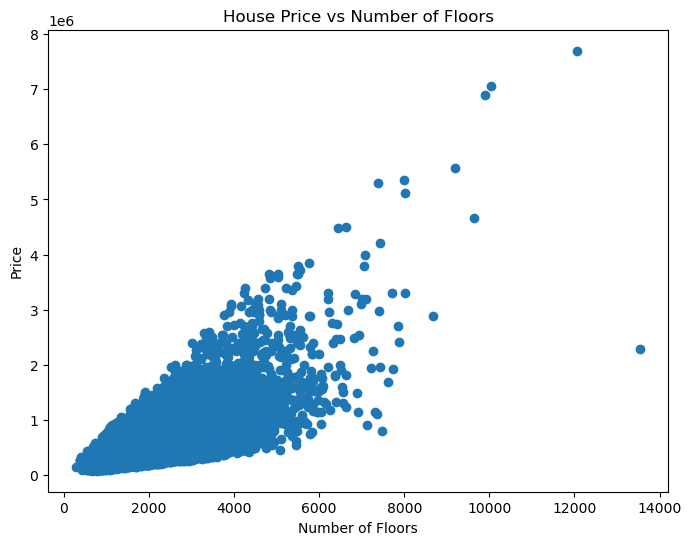

In [3]:
import numpy as np

plt.figure(figsize=(8, 6))

plt.scatter(df["sqft_living"] ,df["price"])

plt.xlabel("Number of Floors")
plt.ylabel("Price")
plt.title("House Price vs Number of Floors")

plt.show()

#### 2. **Check if the data relationship between two variables is linear**

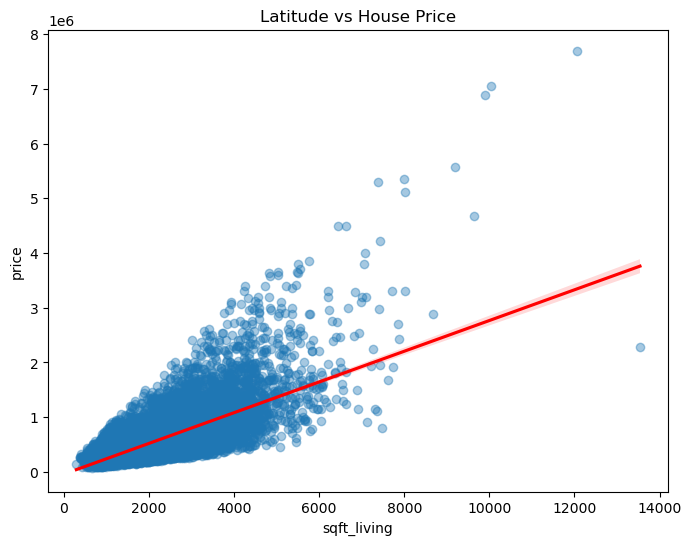

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="sqft_living",
    y="price",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("Latitude vs House Price")
plt.show()


#### we notice that the majority of data are linearly increasing so we use Pearson correlation

In [4]:
#  method 1 using scipy
from scipy.stats import pearsonr

r, p = pearsonr(df["sqft_living"], df["price"])

print("Pearson correlation:", r)
print("P-value:", p)

Pearson correlation: 0.7020437212325271
P-value: 0.0


In [5]:
# method 2 using pandas corr()
corr_matrix = df.corr(method="pearson", numeric_only=True)
corr = corr_matrix.loc["sqft_living", "price"]
print("Pearson Correlation:", corr)

Pearson Correlation: 0.7020437212325301


####  the output is 0.7020437212325301 which means there is a positive relationship between the Area of the house and the price, where the house's price increases with the house area

**Pearson Correlation simulator :** https://rpsychologist.com/correlation/

**Read more about Pearson Correlation :** https://www.geeksforgeeks.org/data-analysis/what-is-correlation-analysis/

### 1.2.2 Numerical Vs Catagorical statistics 

#### Step 1: Visualize
Since one variable is categorical we use one of these to visualize the relationship

- Strip plot
- Box plot
- Violin plot

<Axes: xlabel='floors', ylabel='price'>

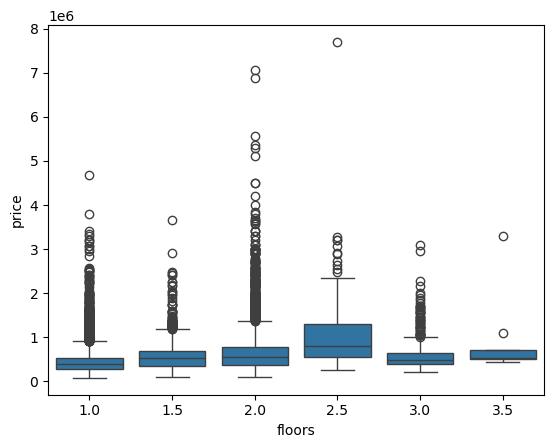

In [105]:
sns.boxplot(data=df, x="floors", y="price")

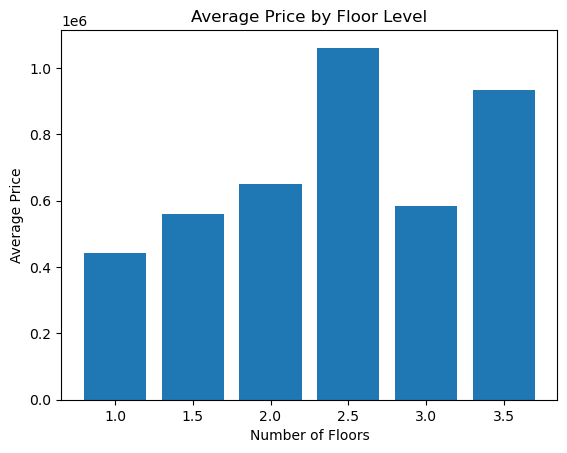

In [97]:
import matplotlib.pyplot as plt

# 1. Group by floors and calculate the average price
df_grouped = df.groupby("floors")["price"].mean().reset_index()

# 2. Plot the grouped data
plt.bar(df_grouped["floors"], df_grouped["price"], width=0.4)
plt.xlabel("Number of Floors")
plt.ylabel("Average Price")
plt.title("Average Price by Floor Level")
plt.show()


#### Step 2: Inspect the relationship

Analyze the diagram

- Do the groups have different medians?
- Are some groups generally more expensive?
- Is there a lot of overlap?
- Are there many outliers?

#### Step 3: Choose the statistical test

The standard test is:

- Two categories → t-test
- Three or more categories → ANOVA

For floors, ANOVA is appropriate because there are several floor levels.

In [111]:
#  create one group for each floor value and use SciPy

from scipy.stats import f_oneway

# Create one group for each floor category
groups = [group["price"].values for _, group in df.groupby("floors")]

# Perform one-way ANOVA
F_statistic, p_value = f_oneway(*groups)

print("F-statistic:", F_statistic)
print("P-value:", p_value)

F-statistic: 399.5893163565707
P-value: 0.0


#### Step4:Interpretation

**p-value < 0.05** → At least one floor category has a significantly different mean price.

**p-value ≥ 0.05** → No statistically significant difference in mean price among the floor categories.

In [109]:
if p_value < 0.05:
    print("There is a statistically significant difference in house prices between floor groups.")
else:
    print("There is no statistically significant difference in house prices between floor groups.")

There is a statistically significant difference in house prices between floor groups.


> ANOVA produced a p-value less than 0.05, suggesting that house prices differ significantly between at least some floor categories.

## P-value and correlation

### Null-hypothesis

## 2. Correlation Heatmap

A **correlation heatmap** is used to visualize the correlation coefficients between numerical variables. It summarizes the strength and direction of the linear relationship between every pair of variables.

Correlation values range from **-1 to 1**:

- **1** → Perfect positive linear relationship
- **0** → No linear relationship
- **-1** → Perfect negative linear relationship

The color intensity helps quickly identify variables that are strongly correlated.

### Step 1: Compute the Correlation Matrix

```python
corr = df.corr(method="pearson", numeric_only=True)
```

### Syntax

```python
DataFrame.corr(method="pearson", numeric_only=True)
```

### Parameters

- **method** : Specifies the correlation coefficient to compute.
  - `"pearson"` → Linear correlation (default)
  - `"spearman"` → Monotonic correlation
  - `"kendall"` → Rank-based correlation
- **numeric_only=True** : Computes correlations only for numerical columns.

### Step 2: Visualize the Correlation Matrix

```python
sns.heatmap(corr, annot=True, cmap="coolwarm")
```

### Syntax

```python
sns.heatmap(data, annot=False, cmap=None)
```

### Parameters

- **data** : The correlation matrix.
- **annot=True** : Displays the numerical correlation value inside each cell.
- **cmap="coolwarm"** : Applies a color gradient where:
  - Blue represents negative correlations.
  - Red represents positive correlations.
  - White represents values close to zero.

### Example

```python
corr = df.corr(method="pearson", numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
```

The heatmap provides a quick overview of which numerical variables are strongly positively or negatively correlated.

**A null hypothesis** is a default statistical assumption stating that there is no effect, no relationship, or no difference between variables, and any observed data variation is due to random chance

**It tests whether the relationship exists between variables or if it was a mere coincidence**

## 3. Pairplot



A **pairplot** is one of the quickest ways to explore relationships between multiple numerical variables. It creates a grid where each numerical feature is plotted against every other numerical feature.

- **Scatter plots** are displayed for each pair of variables.
- **Histograms** or **Kernel Density Estimates (KDE)** are displayed on the diagonal to show the distribution of each variable.
- It is especially useful during the early stages of Exploratory Data Analysis (EDA) to identify:
  - Linear relationships
  - Clusters
  - Outliers
  - Potential correlations
  - Class separation when using a categorical target

### Syntax

```python
sns.pairplot(data, hue=None)
```

### Parameters

- **data** : The DataFrame containing the variables to visualize.
- **hue** *(optional)* : A categorical column used to color the observations, making it easier to distinguish different classes.

### Example

```python
sns.pairplot(df, hue="target")
```


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
df.head()
sns.pairplot(df[["age", "thalach", "oldpeak", "chol", "target"]], hue="target", palette="Set1", corner=True)
plt.suptitle("Pairplot of Key Variables by Target", y=1.02)
plt.show()